# Swarovski Pearl — Ok% (Okper) Prediction — Production Pipeline


## 1. Setup, Configuration & Imports

All paths, magic numbers and knobs live in one `CONFIG` dict so nothing is hard-coded deep inside a function. This is the single place you touch when moving from your laptop to a server / a new data drop.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import json
import time
import logging
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-7s | %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("okper_pipeline")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [ ]:
CONFIG = {
    # ---- data sources ------------------------------------------------
    "raw_data_path": "/content/drive/MyDrive/Job_Profile/Swarovski/Datasets/CP Results 2018 to 6_2024.xlsx",     # <-- adjust
    "dictionary_path": "/content/drive/MyDrive/Job_Profile/Swarovski/Datasets/Swarovski_dictionary.xlsx",         # <-- adjust
    "processed_dir": Path("/content/drive/MyDrive/Job_Profile/Swarovski/Datasets/processed"),
    "report_dir": Path("/content/drive/MyDrive/Job_Profile/Swarovski/Datasets/reports"),
    "model_dir": Path("/content/drive/MyDrive/Job_Profile/Swarovski/Datasets/models"),

    # ---- schema --------------------------------------------------------
    "target": "Okper",
    "date_col": "SFInDate",
    "id_cols": ["Art", "SysNo", "BatchNo", "RBFA"],
    "group_cols": ["ProductNumber", "ColourCode"],   # unit of "a recipe"

    "glass_defects":    ["a110", "b110", "c110", "d110", "e110"],
    "coating_defects":  ["a111", "b111", "c111", "d111", "e111", "f111", "g111", "h111"],
    "removing_defects": ["a112", "b112", "c112", "d112"],

    # columns only known *after* the batch is graded / packed, i.e.
    # downstream of Okper in the real process. These caused the
    # "perfectly correlated" features flagged by v1's correlation-pruning
    # step -- they must never be used as predictors.
    "post_outcome_leak_cols": [
        "Loss", "GDkg", "RCDkg", "PackMonth", "Packyr",
    ],

    # ---- splitting -------------------------------------------------------
    "test_size": 0.2,
    "n_cv_splits": 3,
    "random_state": RANDOM_STATE,

    # ---- feature engineering -------------------------------------------
    "rolling_window": 3,

    # ---- feature selection -----------------------------------------------
    "corr_drop_threshold": 0.95,   # pairwise |corr| among predictors
    "vif_threshold": 10.0,
    "top_k_mi_features": 60,       # cap after mutual-information ranking

    # ---- misc ---------------------------------------------------------
    "n_optuna_trials": 40,
}

CONFIG


{'raw_data_path': '/content/drive/MyDrive/Job_Profile/Swarovski/Datasets/CP Results 2018 to 6_2024.xlsx',
 'dictionary_path': '/content/drive/MyDrive/Job_Profile/Swarovski/Datasets/Swarovski_dictionary.xlsx',
 'processed_dir': PosixPath('/content/drive/MyDrive/Job_Profile/Swarovski/Datasets/processed'),
 'report_dir': PosixPath('/content/drive/MyDrive/Job_Profile/Swarovski/Datasets/reports'),
 'model_dir': PosixPath('/content/drive/MyDrive/Job_Profile/Swarovski/Datasets/models'),
 'target': 'Okper',
 'date_col': 'SFInDate',
 'id_cols': ['Art', 'SysNo', 'BatchNo', 'RBFA'],
 'group_cols': ['ProductNumber', 'ColourCode'],
 'glass_defects': ['a110', 'b110', 'c110', 'd110', 'e110'],
 'coating_defects': ['a111',
  'b111',
  'c111',
  'd111',
  'e111',
  'f111',
  'g111',
  'h111'],
 'removing_defects': ['a112', 'b112', 'c112', 'd112'],
 'post_outcome_leak_cols': ['Loss', 'GDkg', 'RCDkg', 'PackMonth', 'Packyr'],
 'test_size': 0.2,
 'n_cv_splits': 3,
 'random_state': 42,
 'rolling_window': 3,


## 2. Data Loading

The raw workbook has one sheet per year/batch-of-years plus a separate "dictionary" workbook (column glossary, colour-code lookup, product-code lookup). We load defensively: every sheet is tagged with its source sheet name before concatenation, so a schema drift in one sheet is easy to trace instead of silently producing NaNs.

In [ ]:
def load_and_merge_excel(path: str, sort_by: str | None = None, ascending: bool = True) -> pd.DataFrame:
    """Load every sheet of an Excel workbook and concatenate them into one long DataFrame.

    Each row keeps track of which sheet it came from (`__source_sheet`) which is
    invaluable for debugging schema drift across years.
    """
    xls = pd.ExcelFile(path)
    frames = []
    for sheet_name in xls.sheet_names:
        sheet_df = pd.read_excel(path, sheet_name=sheet_name)
        sheet_df["__source_sheet"] = sheet_name
        frames.append(sheet_df)
        logger.info("Loaded sheet '%s' -> %s rows, %s cols", sheet_name, *sheet_df.shape)

    merged = pd.concat(frames, ignore_index=True)

    if sort_by is not None and sort_by in merged.columns:
        merged = merged.sort_values(by=sort_by, ascending=ascending)

    logger.info("Merged workbook '%s': final shape %s", path, merged.shape)
    return merged


def load_dictionary(path: str):
    """Load the 3 reference sheets: column glossary, colour codes, product codes."""
    dictionary = pd.read_excel(path, sheet_name=0)
    colour_code = pd.read_excel(path, sheet_name=1)
    product_code = pd.read_excel(path, sheet_name=2)
    return dictionary, colour_code, product_code


In [ ]:
raw_df = load_and_merge_excel(CONFIG["raw_data_path"])
dictionary, colour_code, product_code = load_dictionary(CONFIG["dictionary_path"])

print("Raw shape:", raw_df.shape)
raw_df.head()


Raw shape: (65318, 61)


,Art,Code,BatchNo,SysNo,RBFA,wCPg,SFINkg,OkQty,GDkg,RCDkg,SFInDate,PackedDate,a110,b110,c110,d110,e110,a111,b111,c111,d111,e111,f111,g111,h111,a112,b112,c112,d112,QtyTheo,SFINNos,GDNos,RCDNos,QtyPer,Okper,GDper,RCDper,totqtyno,a110no,b110no,c110no,d110no,e110no,a111no,b111no,c111no,d111no,e111no,f111no,g111no,h111no,a112no,b112no,c112no,d112no,PackMonth,SFINMonth,Packyr,SFInyr,Loss,__source_sheet
0,A.5810.MM5.0,538,910122589,1000702,93150494.0,17.491,8.664,45801,0.096,0.557,2017-12-05,2018-02-18,0.03,0.00,1.06,0.00,0.02,0.00,0.00,1.61,0.00,1.29,0.0,0.00,0.00,0.0,0.0,2.24,1.29,68080,49534,549,3184,-67.28,92.46,1.11,6.43,49534,15,0,525,0,10,0,0,797,0,639,0,0,0,0,0,1110,639,2,12,2018,2017,27.24,2018
1,A.5810.MM6.0,947,910122468,5271770,93217451.0,30.760,16.628,43598,0.357,2.860,2017-12-08,2018-02-02,0.15,0.06,1.94,0.00,0.00,0.52,0.00,4.30,0.00,1.20,0.0,6.02,2.06,0.0,0.0,1.72,1.38,60720,54057,1161,9298,-71.80,80.65,2.15,17.20,54057,81,32,1049,0,0,281,0,2324,0,649,0,3254,1114,0,0,930,746,2,12,2018,2017,10.97,2018
2,A.5810.MM5.0,948,910122579,5293131,93223377.0,17.491,5.280,22801,0.310,0.982,2017-12-09,2018-01-30,0.71,0.12,5.04,0.00,0.00,0.93,2.98,4.65,0.37,2.79,0.0,2.23,2.05,0.0,0.0,2.42,0.18,68080,30187,1772,5614,-33.49,75.53,5.87,18.60,30187,214,36,1521,0,0,281,900,1404,112,842,0,673,619,0,0,731,54,1,12,2018,2017,55.66,2018
3,A.5810.MM8.0,620,910122702,258171,69.0,73.367,18.947,17149,3.230,3.135,2017-12-11,2018-01-08,0.34,0.68,12.96,3.07,0.00,1.17,0.99,6.29,0.00,1.65,0.0,1.49,0.83,0.0,0.0,3.47,0.66,33480,25825,4403,4273,-51.22,66.40,17.05,16.55,25825,88,176,3347,793,0,302,256,1624,0,426,0,385,214,0,0,896,170,1,12,2018,2017,22.86,2018
4,A.5810.MM3.0,618,910122867,691686,93210576.0,3.485,2.197,56816,0.054,0.163,2017-12-12,2018-01-31,0.07,0.05,2.34,0.00,0.00,0.74,0.37,2.68,0.00,1.34,0.0,0.00,1.49,0.0,0.0,0.67,0.13,119560,63042,1549,4677,-47.52,90.12,2.46,7.42,63042,44,32,1475,0,0,467,233,1690,0,845,0,0,939,0,0,422,82,1,12,2018,2017,47.27,2018


## 3. Data Cleaning

Cleaning is written as pure functions with **assertions and logging at every step**, not silent transformations. In production this is the piece that will break first when the plant changes an Art-code format or adds a new colour — we want that to raise a loud, specific error rather than quietly dropping rows.

In [ ]:
import pandas as pd
import numpy as np
import logging

logger = logging.getLogger(__name__)

def parse_art_code(df: pd.DataFrame) -> pd.DataFrame:
    """Split the "Art" code (e.g. `A.1234.MM4.5`) into ProductNumber and Size."""
    df = df.copy()
    extracted = df["Art"].str.extract(r"A\.(\d+)\.MM([\d\.]+)")
    df["ProductNumber"] = pd.to_numeric(extracted[0], errors="coerce").astype("Float64")

    size_raw = extracted[1].str.replace(r"^\.+", "", regex=True)
    size_raw = size_raw.str.replace(r"\.+", ".", regex=True)
    df["Size"] = pd.to_numeric(size_raw, errors="coerce").astype("Float64")

    n_unparsed = df["ProductNumber"].isna().sum()
    if n_unparsed:
        logger.warning("%d rows failed Art-code parsing (unexpected format)", n_unparsed)
    return df


def clean_colour_code(df: pd.DataFrame) -> pd.DataFrame:
    """Clean the ColourCode column and ensure it is numeric."""
    df = df.rename(columns={"Code": "ColourCode"}).copy()
    df = df[~df["ColourCode"].astype(str).str.strip().isin(["ng", "nd"])].copy()
    df["ColourCode"] = (
        df["ColourCode"].astype(str).str.replace(".0", "", regex=False).replace("nan", np.nan)
    )
    df["ColourCode"] = pd.to_numeric(df["ColourCode"], errors="coerce").astype("Float64")
    return df


def remove_leaky_and_redundant_cols(df: pd.DataFrame) -> pd.DataFrame:
    """Removes columns known after production and redundant identifiers."""

    # 1. Defect codes (e.g., a110, b111no, etc.)
    defect_cols = [col for col in df.columns if col.startswith(('a1', 'b1', 'c1', 'd1', 'e1', 'f1', 'g1', 'h1'))]

    # 2. Hardcoded leaky variables (yield, rejects, post-production dates, etc.)
    leaky_cols = [
        'OkQty', 'GDkg', 'RCDkg', 'PackedDate', 'GDNos', 'RCDNos', 'QtyPer', 'BatchNo',
        'GDper', 'RCDper', 'totqtyno', 'PackMonth', 'Packyr', 'Loss', '__source_sheet'
    ]

    # 3. Redundant variables (Already parsed into ProductNumber, Size, and ColourCode)
    redundant_cols = ['Art', 'ProductDesc', 'ColourDesc']

    # Combine lists and drop if they exist in the dataframe
    cols_to_drop = defect_cols + leaky_cols + redundant_cols
    existing_cols_to_drop = [c for c in cols_to_drop if c in df.columns]

    df = df.drop(columns=existing_cols_to_drop)
    return df


def clean_dataset(df: pd.DataFrame, target: str = 'Okper') -> pd.DataFrame:
    """Full cleaning pipeline. Returns a clean, de-duplicated, leakage-free DataFrame."""
    n0 = len(df)

    df = clean_colour_code(df)
    df = parse_art_code(df)

    # Convert specific identifiers to string
    for col in ["ProductNumber", "ColourCode", "RBFA", "SysNo", "BatchNo"]:
        if col in df.columns:
            df[col] = df[col].astype(str)

    # Drop rows with no parseable Size or missing target
    df = df.dropna(subset=["Size", target]).copy()

    # Target must be a valid percentage
    df = df[(df[target] >= 0) & (df[target] <= 100)].copy()

    # Drop Leaky and Redundant Columns
    df = remove_leaky_and_redundant_cols(df)

    # Exact duplicate rows
    n_dupes = df.duplicated().sum()
    if n_dupes:
        logger.warning("Dropping %d exact duplicate rows", n_dupes)
        df = df.drop_duplicates()

    # Standardize column order (putting target at the end)
    front_cols = ["ProductNumber", "Size", "ColourCode", "BatchNo", "SysNo"]
    front_cols = [c for c in front_cols if c in df.columns]
    other_cols = [c for c in df.columns if c not in front_cols and c != target]

    df = df[front_cols + other_cols + [target]]

    logger.info("Cleaning: %d -> %d rows (%.1f%% kept)", n0, len(df), 100 * len(df) / n0)
    return df.reset_index(drop=True)

In [ ]:
clean_df = clean_dataset(raw_df)
print(clean_df.shape)
clean_df.head()


(63715, 13)


,ProductNumber,Size,ColourCode,SysNo,RBFA,wCPg,SFINkg,SFInDate,QtyTheo,SFINNos,SFINMonth,SFInyr,Okper
0,5810.0,5.0,538.0,1000702,93150494.0,17.491,8.664,2017-12-05,68080,49534,12,2017,92.46
1,5810.0,6.0,947.0,5271770,93217451.0,30.760,16.628,2017-12-08,60720,54057,12,2017,80.65
2,5810.0,5.0,948.0,5293131,93223377.0,17.491,5.280,2017-12-09,68080,30187,12,2017,75.53
3,5810.0,8.0,620.0,258171,69.0,73.367,18.947,2017-12-11,33480,25825,12,2017,66.40
4,5810.0,3.0,618.0,691686,93210576.0,3.485,2.197,2017-12-12,119560,63042,12,2017,90.12


In [ ]:
for col in clean_df.columns:
    num_unique = clean_df[col].nunique()
    print(f"Column '{col}': {num_unique} unique values")

Column 'ProductNumber': 15 unique values
Column 'Size': 19 unique values
Column 'ColourCode': 114 unique values
Column 'SysNo': 1611 unique values
Column 'RBFA': 5827 unique values
Column 'wCPg': 1811 unique values
Column 'SFINkg': 21909 unique values
Column 'SFInDate': 2031 unique values
Column 'QtyTheo': 299 unique values
Column 'SFINNos': 33012 unique values
Column 'SFINMonth': 12 unique values
Column 'SFInyr': 8 unique values
Column 'Okper': 6701 unique values


In [ ]:
# Data-quality report: missing values, dtypes, cardinality -- always look at this
# before trusting anything downstream.
def data_quality_report(df: pd.DataFrame) -> pd.DataFrame:
    report = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_missing": df.isna().sum(),
        "pct_missing": (100 * df.isna().mean()).round(2),
        "n_unique": df.nunique(),
    }).sort_values("pct_missing", ascending=False)
    return report

dq_report = data_quality_report(clean_df)
dq_report[dq_report["n_missing"] > 0]


,dtype,n_missing,pct_missing,n_unique


In [ ]:
# Persist the cleaned dataset so EDA / feature-engineering cells can be re-run
# independently without re-parsing the raw Excel workbook every time.
clean_df.to_parquet(CONFIG["processed_dir"] / "clean_dataset.parquet")
dictionary.to_parquet(CONFIG["processed_dir"] / "dictionary.parquet")
logger.info("Saved cleaned dataset -> %s", CONFIG["processed_dir"] / "clean_dataset.parquet")


## 4. Exploratory Data Analysis (EDA)

We look at the target distribution, then each driver family in turn (product, colour, size, defects, weight, time) and record what we learn as we go -- these notes directly justify the feature-engineering choices in Section 5.

In [ ]:
TARGET = CONFIG["target"]
df = pd.read_parquet(CONFIG["processed_dir"] / "clean_dataset.parquet")
print(df.shape)
df[TARGET].describe()


(63715, 13)


,Okper
count,63715.000000
mean,79.918659
std,16.151884
min,25.000000
25%,71.180000
50%,84.530000
75%,91.020000
max,100.000000


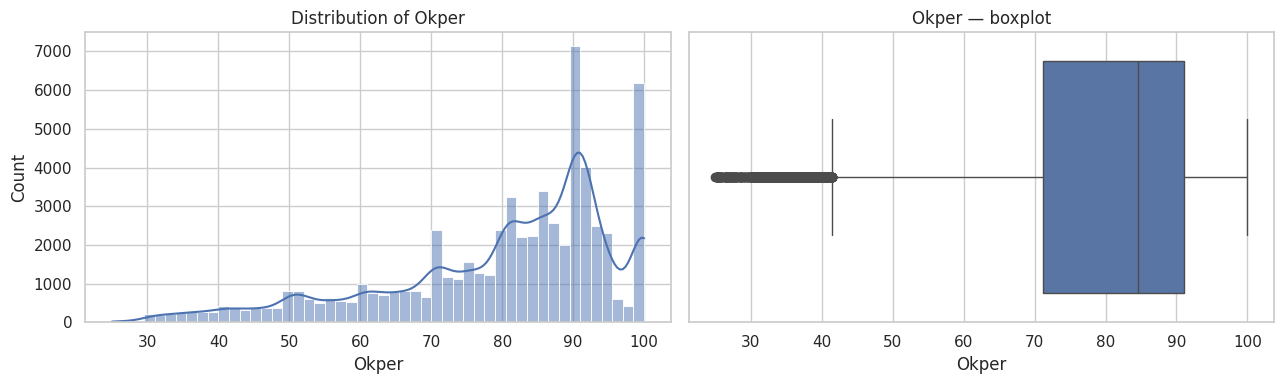

Skewness: -1.049 | Kurtosis: 0.478


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df[TARGET], bins=50, kde=True, ax=axes[0])
axes[0].set_title(f"Distribution of {TARGET}")
sns.boxplot(x=df[TARGET], ax=axes[1])
axes[1].set_title(f"{TARGET} — boxplot")
plt.tight_layout()
plt.show()

print(f"Skewness: {df[TARGET].skew():.3f} | Kurtosis: {df[TARGET].kurt():.3f}")


### 4.1 Target vs numeric features — correlation snapshot

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])
target_corr = numeric_df.corrwith(df[TARGET]).abs().sort_values(ascending=False)
print("Absolute correlation with target (top 25):")
target_corr.head(25)


Absolute correlation with target (top 25):


,0
Okper,1.000000
Size,0.550788
wCPg,0.511665
SFINNos,0.345657
QtyTheo,0.149037
SFInyr,0.118155
SFINkg,0.007624
SFINMonth,0.003679


### 4.2 ProductDesc

,count,mean,std
ProductNumber,,,
5844.0,72,50.615972,10.733055
5842.0,115,58.588000,16.488036
5843.0,79,61.366709,14.495501
5816.0,126,62.805714,17.649388
5860.0,116,63.385603,11.932012
5841.0,140,64.056143,14.270480
5811.0,1090,64.299615,24.286971
5821.0,189,65.937513,17.083141
5840.0,456,69.711272,23.378098


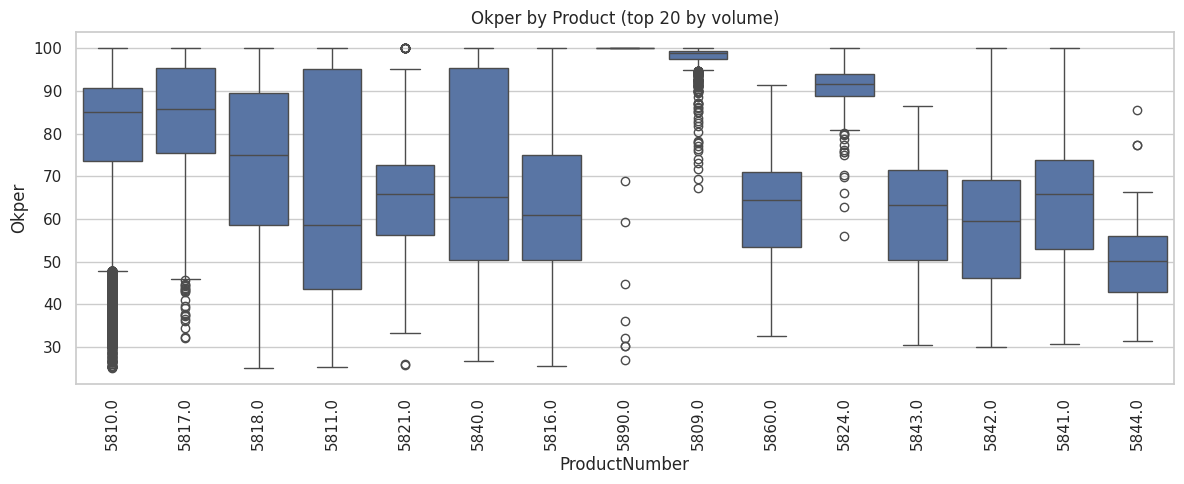

In [ ]:
prod_stats = df.groupby("ProductNumber")[TARGET].agg(["count", "mean", "std"]).sort_values("mean")
display(prod_stats)

top_products = df["ProductNumber"].value_counts().head(20).index
plt.figure(figsize=(12, 5))
sns.boxplot(x="ProductNumber", y=TARGET, data=df[df["ProductNumber"].isin(top_products)])
plt.xticks(rotation=90)
plt.title(f"{TARGET} by Product (top 20 by volume)")
plt.tight_layout()
plt.show()


### 4.3 ColourDesc

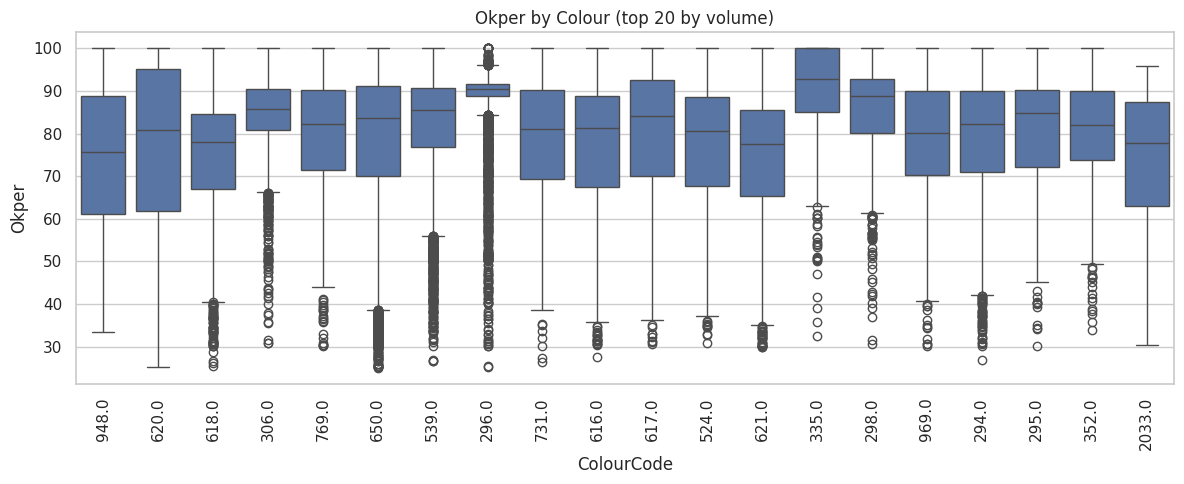

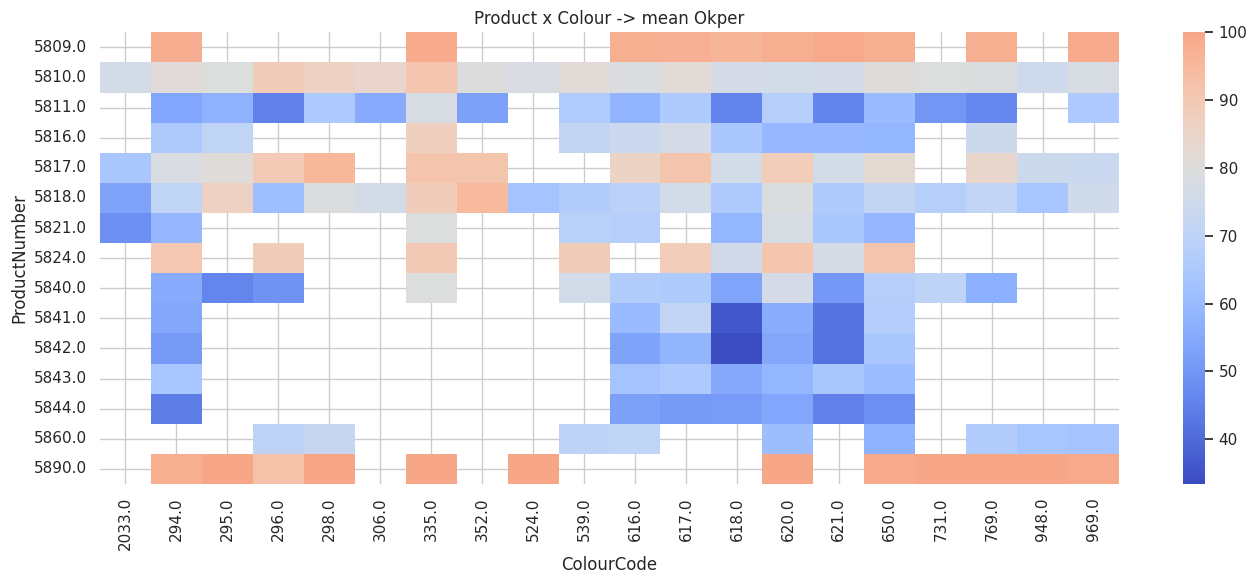

In [ ]:
top_colours = df["ColourCode"].value_counts().head(20).index
plt.figure(figsize=(12, 5))
sns.boxplot(x="ColourCode", y=TARGET, data=df[df["ColourCode"].isin(top_colours)])
plt.xticks(rotation=90)
plt.title(f"{TARGET} by Colour (top 20 by volume)")
plt.tight_layout()
plt.show()

pivot = df[df["ColourCode"].isin(top_colours)].pivot_table(
    values=TARGET, index="ProductNumber", columns="ColourCode", aggfunc="mean")
plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap="coolwarm", center=df[TARGET].mean())
plt.title(f"Product x Colour -> mean {TARGET}")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


### 4.4 Size

,count,mean,std
Size,,,
12.0,3583,58.173835,22.396604
16.0,41,59.601463,14.414432
15.0,106,60.186038,16.616334
9.0,160,61.599937,10.755835
11.0,189,65.937513,17.083141
10.0,6212,66.136125,19.986823
7.0,450,69.954133,14.145289
8.0,11598,74.693733,15.206905
11.5,20,76.690000,16.802145


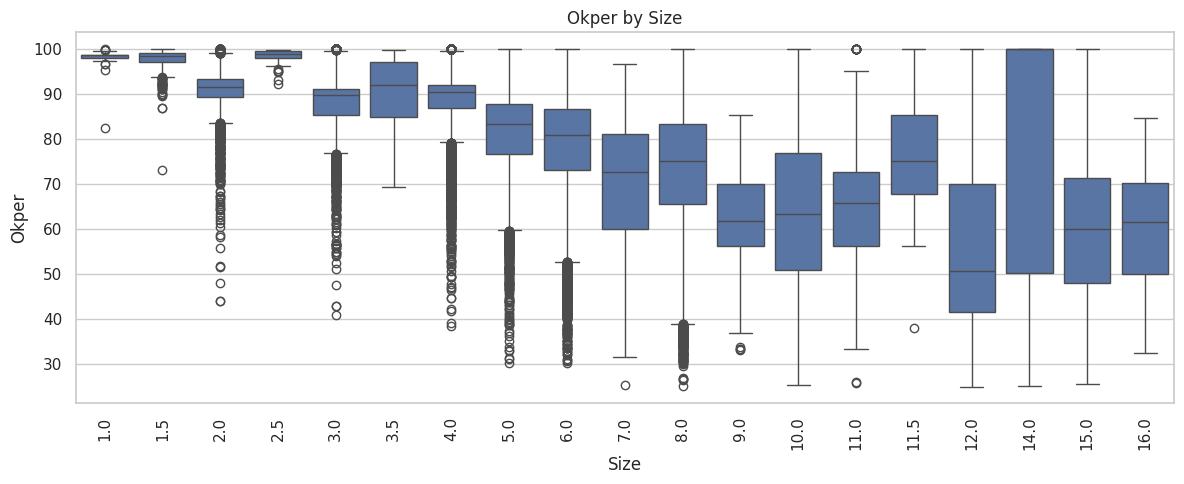

In [ ]:
size_stats = df.groupby("Size")[TARGET].agg(["count", "mean", "std"]).sort_values("mean")
display(size_stats)

plt.figure(figsize=(12, 5))
sns.boxplot(x="Size", y=TARGET, data=df)
plt.xticks(rotation=90)
plt.title(f"{TARGET} by Size")
plt.tight_layout()
plt.show()


### 4.5 Defect features

Defects are grouped by manufacturing stage: **glass** forming, **coating**, and **removing/handling**. We check both the individual defect codes and the stage-level sums against the target.

In [ ]:
defect_cols = CONFIG["glass_defects"] + CONFIG["coating_defects"] + CONFIG["removing_defects"]
present_defect_cols = [c for c in defect_cols if c in df.columns]

print(df[present_defect_cols + [TARGET]].corr()[TARGET].sort_values())


Okper    1.0
Name: Okper, dtype: float64


### 4.7 Time-related fields

Seasonality / drift over years matters both as a feature and as a reason to use a **time-based split** later on.

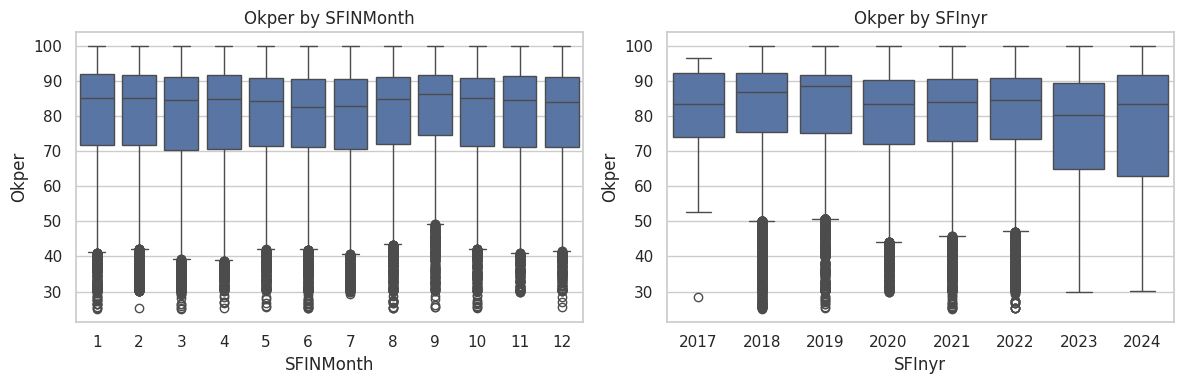

In [ ]:
time_cols = [c for c in ["SFINMonth", "SFInyr"] if c in df.columns]
fig, axes = plt.subplots(1, len(time_cols), figsize=(6 * len(time_cols), 4))
if len(time_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, time_cols):
    sns.boxplot(x=col, y=TARGET, data=df, ax=ax)
    ax.set_title(f"{TARGET} by {col}")
plt.tight_layout()
plt.show()


### 4.8 EDA takeaways

- `Okper` is left-skewed (most batches run well, a tail of bad batches drags the mean down) — worth comparing RMSE-optimizing vs MAE-optimizing objectives later.
- `ProductDesc`, `ColourDesc` and `Size` all show real separation in mean `Okper` and in variance ⇒ good candidates for historical-mean / historical-std features AND for interaction features (Product×Colour, Product×Size).
- Stage-level defect sums correlate with `Okper` more cleanly than most individual defect codes ⇒ engineer them explicitly, keep the individual codes only if they add signal beyond the stage sum (checked in feature selection).
- There's a visible year/month effect ⇒ include calendar features **and** validate with a time-aware split, not a random one.

## 5. Outlier Detection

Production data has genuine extreme values (a truly bad batch) as well as data-entry errors (a `Size` typo, a defect count in the thousands). We want to **flag**, not blindly delete, so quality analysts can audit; deleting silently would hide real quality events from the model. Three complementary views: IQR per numeric column, robust Z-score, and a multivariate `IsolationForest` pass.

In [ ]:
def iqr_outlier_flags(series: pd.Series, k: float = 1.5) -> pd.Series:
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return (series < lower) | (series > upper)


numeric_cols_for_outliers = ["Okper", "Size", "wCPg", "SFINkg"] + present_defect_cols
numeric_cols_for_outliers = [c for c in numeric_cols_for_outliers if c in df.columns]

outlier_summary = {}
for col in numeric_cols_for_outliers:
    flags = iqr_outlier_flags(df[col].astype(float))
    outlier_summary[col] = flags.sum()

pd.Series(outlier_summary, name="n_outliers_iqr").sort_values(ascending=False)


,n_outliers_iqr
wCPg,4293
Okper,2114
SFINkg,1122
Size,147


**Decision:** keep all rows in the modeling set, but carry `_is_outlier_iforest` as a boolean *feature* rather than deleting rows — tree-based models handle it fine, and it lets the model learn "this batch's inputs looked unusual" as a signal. Rows with an impossible `Okper` (outside [0,100]) were already dropped during cleaning (Section 3). Gross physical impossibilities (e.g. `Size <= 0`, `wCPg <= 0`) are dropped here since those cannot be legitimate measurements.

In [ ]:
physically_impossible = pd.Series(False, index=df.index)
for col, min_valid in [("Size", 0), ("wCPg", 0), ("SFINkg", 0)]:
    if col in df.columns:
        physically_impossible |= (df[col] <= min_valid)

logger.info("Dropping %d physically-impossible rows", physically_impossible.sum())
df = df[~physically_impossible].copy()
df.shape


(63713, 13)

## 6. Feature Engineering

Two families of engineered features:

1. **Static / row-level** features — derived purely from that row's own values (defect-stage sums, size bins, calendar parts, interaction keys). Safe to compute any time, on any split.
2. **Historical group-aggregate** features — "what has this Product/Colour done on average *in the past*?". These are powerful (v1's correlation analysis showed `Product_mean` / `Colour_mean` were the strongest predictors) but are exactly where leakage happens if you're not careful. We implement them as a proper **`scikit-learn` transformer** that:
   - is `fit()` only on the training rows,
   - stores one aggregate value per group key,
   - on `transform()`, looks the value up for every row (train **or** test) by key, falling back to the *global training* mean for a group never seen in training.

This guarantees the test set never contributes to its own features, and that a brand-new Product/Colour combination at inference time degrades gracefully instead of crashing.

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin


class GroupAggregateFeatures(BaseEstimator, TransformerMixin):
    """Leakage-safe historical group statistics.

    For each `group_cols` combination, computes {mean, std, count} of `target`
    seen during `fit`, and looks those up during `transform`. Unseen groups (or
    groups with too few samples) fall back to the global training mean/std.

    This is deliberately *not* time-aware inside a single fit (it uses the whole
    training fold's average, not a strictly-causal expanding average) -- that
    tradeoff is intentional: it is simple, leakage-safe across train/test, and is
    re-fit inside every CV fold by the surrounding Pipeline/cross_val_score call,
    which is what actually protects against leakage. A stricter, fully causal
    version (`ExpandingGroupFeatures` below) is provided for the time-series
    experiments in Section 10.
    """

    def __init__(self, group_cols, target_col, prefix, min_samples_for_group=3):
        self.group_cols = group_cols
        self.target_col = target_col
        self.prefix = prefix
        self.min_samples_for_group = min_samples_for_group

    def fit(self, X, y=None):
        data = X.copy()
        if y is None:
            raise ValueError("GroupAggregateFeatures needs y (the target) during fit.")
        data[self.target_col] = np.asarray(y)

        grouped = data.groupby(self.group_cols)[self.target_col]
        stats = grouped.agg(["mean", "std", "count"])
        stats.loc[stats["count"] < self.min_samples_for_group, ["mean", "std"]] = np.nan

        self.group_stats_ = stats
        self.global_mean_ = float(np.mean(y))
        self.global_std_ = float(np.std(y))
        return self

    def transform(self, X):
        X = X.copy()
        merged = X[self.group_cols].merge(
            self.group_stats_, left_on=self.group_cols, right_index=True, how="left"
        )
        X[f"{self.prefix}_mean"] = merged["mean"].fillna(self.global_mean_).values
        X[f"{self.prefix}_std"] = merged["std"].fillna(self.global_std_).values
        X[f"{self.prefix}_n_hist"] = merged["count"].fillna(0).values
        return X

    def get_feature_names_out(self, input_features=None):
        return np.array([f"{self.prefix}_mean", f"{self.prefix}_std", f"{self.prefix}_n_hist"])


In [ ]:
def add_static_features(df: pd.DataFrame, cfg: dict) -> pd.DataFrame:
    """Row-level feature engineering: safe to run on any split, any time."""
    df = df.copy()

    # --- size binning --------------------------------------------------
    df["Size_bin"] = pd.cut(
        df["Size"].astype(float), bins=[0, 4, 8, 12, 20],
        labels=["Small", "Medium", "Large", "Very Large"],
    ).astype(str)

    # --- calendar features from the inspection date -----------------------
    date_col = cfg["date_col"]
    if date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
        df[f"{date_col}_year"]  = df[date_col].dt.year
        df[f"{date_col}_month"] = df[date_col].dt.month
        df[f"{date_col}_doy"]   = df[date_col].dt.dayofyear
        df[f"{date_col}_month_sin"] = np.sin(2 * np.pi * df[f"{date_col}_month"] / 12)
        df[f"{date_col}_month_cos"] = np.cos(2 * np.pi * df[f"{date_col}_month"] / 12)

    # --- interaction keys (used by GroupAggregateFeatures downstream) -----
    df["Product_Colour_key"] = df["ProductNumber"].astype(str) + "_" + df["ColourCode"].astype(str)
    df["Product_Size_key"]   = df["ProductNumber"].astype(str) + "_" + df["Size"].astype(str)

    # --- simple ratios ---------------------------------------------------
    if {"wCPg", "SFINkg"}.issubset(df.columns):
        df["weight_per_kg_ratio"] = df["wCPg"] / df["SFINkg"].replace(0, np.nan)

    return df


### 6.1 Strictly-causal (expanding) group features — for the time-series experiment

For the time-based validation in Section 10 we additionally provide a version of the historical features that only ever looks at **prior-in-time** batches of the same Product/Colour — i.e. true "as-of-now" features, matching how this model would actually be used in production (predict yield for a batch that hasn't finished yet, using only batches that finished before it).

In [ ]:
def add_expanding_group_features(df: pd.DataFrame, group_cols, target_col,
                                  date_col, prefix, rolling_window=3) -> pd.DataFrame:
    """Strictly causal, row-wise expanding statistics: at row i, only uses rows of the
    same group with an earlier date. Requires df to be pre-sorted by date_col.
    """
    df = df.sort_values(date_col).copy()
    grouped_target = df.groupby(group_cols)[target_col]

    df[f"{prefix}_hist_mean"] = grouped_target.transform(lambda s: s.shift().expanding().mean())
    df[f"{prefix}_hist_std"] = grouped_target.transform(lambda s: s.shift().expanding().std())
    df[f"{prefix}_hist_last"] = grouped_target.transform(lambda s: s.shift(1))
    df[f"{prefix}_hist_rolling_mean"] = grouped_target.transform(
        lambda s: s.shift().rolling(rolling_window).mean()
    )
    df[f"{prefix}_cum_count"] = df.groupby(group_cols).cumcount()

    # cold-start rows (no prior history) fall back to the training-global mean,
    # filled later once we know the training split.
    return df


In [ ]:
df_feat = add_static_features(df, CONFIG)
df_feat = df_feat.sort_values(CONFIG["date_col"]).reset_index(drop=True)

df_feat = add_expanding_group_features(
    df_feat, CONFIG["group_cols"], TARGET, CONFIG["date_col"],
    prefix="pc", rolling_window=CONFIG["rolling_window"],
)
df_feat = add_expanding_group_features(
    df_feat, ["ProductNumber"], TARGET, CONFIG["date_col"],
    prefix="prod", rolling_window=CONFIG["rolling_window"],
)
df_feat = add_expanding_group_features(
    df_feat, ["ColourCode"], TARGET, CONFIG["date_col"],
    prefix="colour", rolling_window=CONFIG["rolling_window"],
)

print(df_feat.shape)
new_cols = [c for c in df_feat.columns if c not in df.columns]
df_feat[new_cols].head()


(63713, 37)


,Size_bin,SFInDate_year,SFInDate_month,SFInDate_doy,SFInDate_month_sin,SFInDate_month_cos,Product_Colour_key,Product_Size_key,weight_per_kg_ratio,pc_hist_mean,pc_hist_std,pc_hist_last,pc_hist_rolling_mean,pc_cum_count,prod_hist_mean,prod_hist_std,prod_hist_last,prod_hist_rolling_mean,prod_cum_count,colour_hist_mean,colour_hist_std,colour_hist_last,colour_hist_rolling_mean,colour_cum_count
0,Medium,2017,11,330,-5.000000e-01,0.866025,5810.0_340.0,5810.0_8.0,7.453825,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0
1,Medium,2017,12,339,-2.449294e-16,1.000000,5810.0_538.0,5810.0_5.0,2.018813,NaN,NaN,NaN,NaN,0,68.950000,NaN,68.95,NaN,1,NaN,NaN,NaN,NaN,0
2,Medium,2017,12,342,-2.449294e-16,1.000000,5810.0_947.0,5810.0_6.0,1.849892,NaN,NaN,NaN,NaN,0,80.705000,16.624080,92.46,NaN,2,NaN,NaN,NaN,NaN,0
3,Medium,2017,12,343,-2.449294e-16,1.000000,5810.0_948.0,5810.0_5.0,3.312689,NaN,NaN,NaN,NaN,0,80.686667,11.755043,80.65,80.686667,3,NaN,NaN,NaN,NaN,0
4,Medium,2017,12,345,-2.449294e-16,1.000000,5810.0_620.0,5810.0_8.0,3.872223,NaN,NaN,NaN,NaN,0,79.397500,9.938234,75.53,82.880000,4,NaN,NaN,NaN,NaN,0


In [ ]:
# Drop columns that are only known *after* Okper is measured -- these are not
# predictors, they're consequences (this is what v1 accidentally fed the model).
leak_cols = [c for c in CONFIG["post_outcome_leak_cols"] if c in df_feat.columns]
logger.info("Dropping post-outcome / leakage columns: %s", leak_cols)
df_feat = df_feat.drop(columns=leak_cols)

df_feat.to_parquet(CONFIG["processed_dir"] / "featured_dataset.parquet")
df_feat.shape


(63713, 37)

## 7. Train / Test Split — Time-Based

Because the expanding-window features in Section 6.1 are only valid moving forward in time, and because in production this model always predicts a **not-yet-finished** batch, the held-out test set must be the **most recent** slice of time, not a random 20%. A random split would let the model "see" the future through group-aggregate features and give an overly optimistic score.

In [ ]:
df_feat = pd.read_parquet(CONFIG["processed_dir"] / "featured_dataset.parquet")
df_feat = df_feat.sort_values(CONFIG["date_col"]).reset_index(drop=True)

split_idx = int(len(df_feat) * (1 - CONFIG["test_size"]))
split_date = df_feat.iloc[split_idx][CONFIG["date_col"]]
print("Time-based split date:", split_date)

train_df = df_feat.iloc[:split_idx].copy()
test_df  = df_feat.iloc[split_idx:].copy()
print(f"Train: {train_df.shape}  ({train_df[CONFIG['date_col']].min()} -> {train_df[CONFIG['date_col']].max()})")
print(f"Test : {test_df.shape}  ({test_df[CONFIG['date_col']].min()} -> {test_df[CONFIG['date_col']].max()})")


Time-based split date: 2023-06-02 00:00:00
Train: (50970, 37)  (2017-11-26 00:00:00 -> 2023-06-02 00:00:00)
Test : (12743, 37)  (2023-06-02 00:00:00 -> 2024-06-30 00:00:00)


In [ ]:
# Cold-start rows in the (causal) expanding features have NaN history -- fill with
# the *training* global mean/std only (no leakage from test into train, and no
# leakage from test into itself either since we use train stats for both).
hist_cols = [c for c in df_feat.columns if c.endswith(("_hist_mean", "_hist_std", "_hist_last", "_hist_rolling_mean"))]
train_fill_values = train_df[hist_cols].mean()

train_df[hist_cols] = train_df[hist_cols].fillna(train_fill_values)
test_df[hist_cols]  = test_df[hist_cols].fillna(train_fill_values)

X_train_full = train_df.drop(columns=[TARGET])
y_train_full = train_df[TARGET]
X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]


## 8. Feature Selection

A four-stage funnel, each stage cheap and interpretable, each fit **on the training set only**:

1. **Drop non-predictive columns**: identifiers, free text, the raw defect-% columns that are 1:1 derived from the raw defect counts we already engineered.
2. **Variance / cardinality filter**: constant columns and near-unique ID-like categoricals carry no generalizable signal.
3. **Multicollinearity pruning**: pairwise correlation (numeric) + condition-based VIF check, so two models don't have to fight over the same information and coefficients stay interpretable for the linear baselines.
4. **Mutual-information ranking**: a model-agnostic relevance score used to cap the feature set to a manageable, high-signal size before the more expensive model-based importance pass in Section 13.

In [ ]:
def drop_non_predictive_columns(X: pd.DataFrame, cfg: dict) -> pd.DataFrame:
    drop_cols = set(cfg["id_cols"]) | {"Art", "__source_sheet", cfg["date_col"]}
    # raw per-code defect % columns are superseded by the engineered stage sums
    # and the expanding historical defect features would be added the same way
    # in Section 6.1 if desired -- keep the notebook lean by relying on the sums.
    drop_cols |= set(c for c in X.columns if c.endswith("no"))  # e.g. a110no counts
    drop_cols = [c for c in drop_cols if c in X.columns]
    logger.info("Dropping %d non-predictive / identifier columns", len(drop_cols))
    return X.drop(columns=drop_cols)


X_train_sel = drop_non_predictive_columns(X_train_full, CONFIG)
X_test_sel = X_test[X_train_sel.columns]
X_train_sel.shape


(50970, 33)

In [ ]:
# ---- Stage 2: variance / cardinality filter --------------------------------
numeric_cols = X_train_sel.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train_sel.select_dtypes(exclude=[np.number]).columns.tolist()

# constant numeric columns
zero_var_cols = [c for c in numeric_cols if X_train_sel[c].nunique(dropna=False) <= 1]

# near-unique categoricals behave like row IDs -> cannot generalize
high_card_cols = [
    c for c in categorical_cols
    if X_train_sel[c].nunique() > 0.5 * len(X_train_sel)
]

drop_stage2 = zero_var_cols + high_card_cols
logger.info("Stage 2 drops (zero-variance / near-unique): %s", drop_stage2)

X_train_sel = X_train_sel.drop(columns=drop_stage2)
X_test_sel = X_test_sel.drop(columns=drop_stage2)
numeric_cols = [c for c in numeric_cols if c not in drop_stage2]
categorical_cols = [c for c in categorical_cols if c not in drop_stage2]
X_train_sel.shape


(50970, 33)

In [ ]:
# ---- Stage 3a: pairwise correlation pruning (numeric) ----------------------
corr_matrix = X_train_sel[numeric_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
corr_drop = [c for c in upper.columns if any(upper[c] > CONFIG["corr_drop_threshold"])]
logger.info("Stage 3a drops (|corr| > %.2f): %s", CONFIG["corr_drop_threshold"], corr_drop)

X_train_sel = X_train_sel.drop(columns=corr_drop)
X_test_sel = X_test_sel.drop(columns=corr_drop)
numeric_cols = [c for c in numeric_cols if c not in corr_drop]


In [ ]:
# ---- Stage 3b: VIF (multicollinearity beyond pairwise correlation) --------
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
import pandas as pd

def compute_vif(X_numeric: pd.DataFrame) -> pd.Series:
    X_clean = X_numeric.apply(pd.to_numeric, errors='coerce')
    X_clean = X_clean.dropna(axis=1, how='all')

    X_clean = X_clean.fillna(X_clean.median())
    X_clean = X_clean.astype(float)

    # 5. Handle edge case: if a column has zero variance (constant), VIF goes to infinity or crashes
    # Add a tiny amount of random noise or drop constant columns if needed
    constant_cols = [col for col in X_clean.columns if X_clean[col].nunique() <= 1]
    if constant_cols:
        logger.warning("Dropping constant columns before VIF calculation: %s", constant_cols)
        X_clean = X_clean.drop(columns=constant_cols)

    # 6. Compute VIF scores
    vifs = pd.Series(
        [variance_inflation_factor(X_clean.values, i) for i in range(X_clean.shape[1])],
        index=X_clean.columns,
    )
    return vifs.sort_values(ascending=False)

vif_scores = compute_vif(X_train_sel[numeric_cols])
print(vif_scores.head(15))

vif_drop = vif_scores[vif_scores > CONFIG["vif_threshold"]].index.tolist()
logger.info("Stage 3b drops (VIF > %s): %s", CONFIG["vif_threshold"], vif_drop)

X_train_sel = X_train_sel.drop(columns=vif_drop)
X_test_sel = X_test_sel.drop(columns=vif_drop)
numeric_cols = [c for c in numeric_cols if c not in vif_drop]


SFInyr                      2728.754594
colour_hist_mean            1459.986597
prod_hist_mean              1351.996720
pc_hist_mean                 873.440735
pc_hist_rolling_mean         155.446215
colour_hist_rolling_mean     143.434788
prod_hist_rolling_mean       133.509168
prod_hist_std                128.467599
colour_hist_std               97.739782
pc_hist_last                  62.219408
pc_hist_std                   61.144842
colour_hist_last              53.587529
prod_hist_last                53.307844
Size                          46.796181
pc_cum_count                  12.156631
dtype: float64


In [ ]:
# ---- Stage 4: mutual information ranking (numeric + encoded categorical) -
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import OrdinalEncoder

mi_input = X_train_sel.copy()
if categorical_cols:
    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    mi_input[categorical_cols] = enc.fit_transform(mi_input[categorical_cols].astype(str))
mi_input[numeric_cols] = mi_input[numeric_cols].fillna(mi_input[numeric_cols].median())

mi_scores = mutual_info_regression(
    mi_input, y_train_full, discrete_features=[c in categorical_cols for c in mi_input.columns],
    random_state=RANDOM_STATE,
)
mi_series = pd.Series(mi_scores, index=mi_input.columns).sort_values(ascending=False)
print(mi_series.head(30))

top_k = CONFIG["top_k_mi_features"]
selected_features = mi_series.head(top_k).index.tolist()
logger.info("Kept top %d features by mutual information (of %d candidates)", top_k, len(mi_series))

X_train_final = X_train_sel[selected_features]
X_test_final = X_test_sel[selected_features]
X_train_final.shape


weight_per_kg_ratio    0.687085
QtyTheo                0.657338
Product_Size_key       0.601736
SFINkg                 0.421253
Size_bin               0.412719
Product_Colour_key     0.347658
prod_cum_count         0.277026
ColourCode             0.181370
ProductNumber          0.174037
SFInDate_month_cos     0.012480
SFInDate_month_sin     0.009499
dtype: float64


(50970, 11)

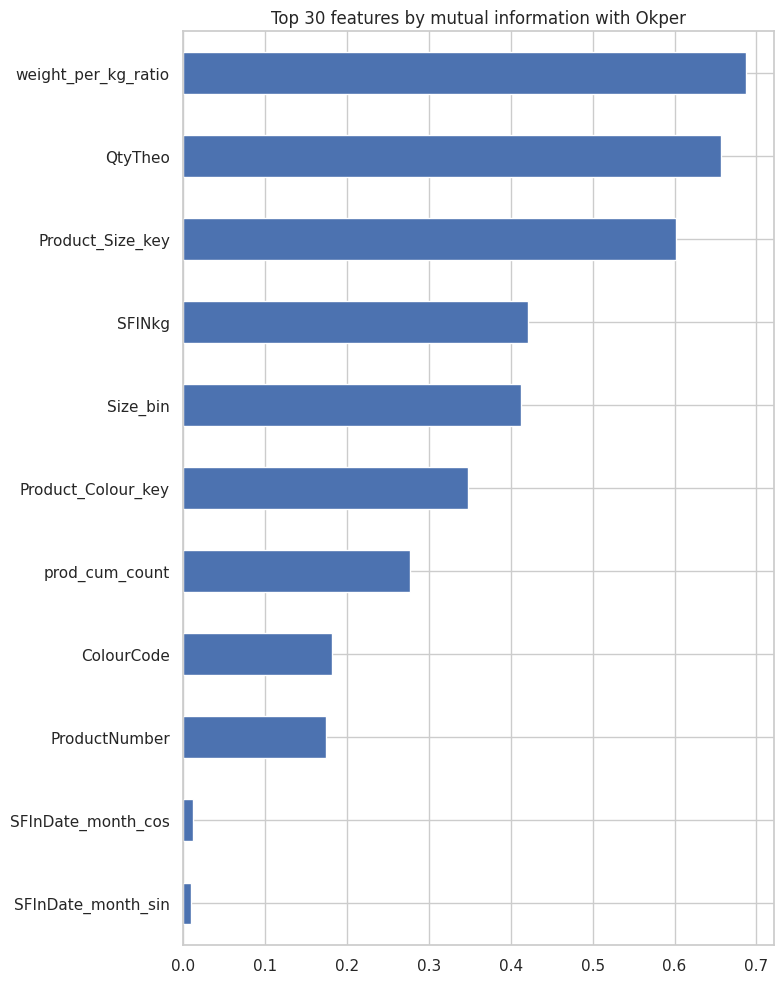

In [ ]:
plt.figure(figsize=(8, 10))
mi_series.head(30).sort_values().plot(kind="barh")
plt.title("Top 30 features by mutual information with Okper")
plt.tight_layout()
plt.show()


## 9. Dimensionality Reduction (PCA)

Tree-based models (our strongest candidates, per Section 11) don't need PCA — they're invariant to monotonic feature transforms and handle correlated features natively. We still run PCA for three genuinely useful reasons:

1. **Visual diagnostics** — project the (scaled) numeric feature space to 2D/3D and see whether `Okper` separates in a way that hints at missing features or unmodeled clusters (e.g. two production lines behaving very differently).
2. **Explained-variance analysis** — quantify how much redundancy is left after feature selection (a sanity check on Section 8).
3. **A genuine PCA-as-features experiment** for the linear/distance-based models (Ridge, SVR, KNN), where collapsing correlated numeric groups into orthogonal components can measurably help.

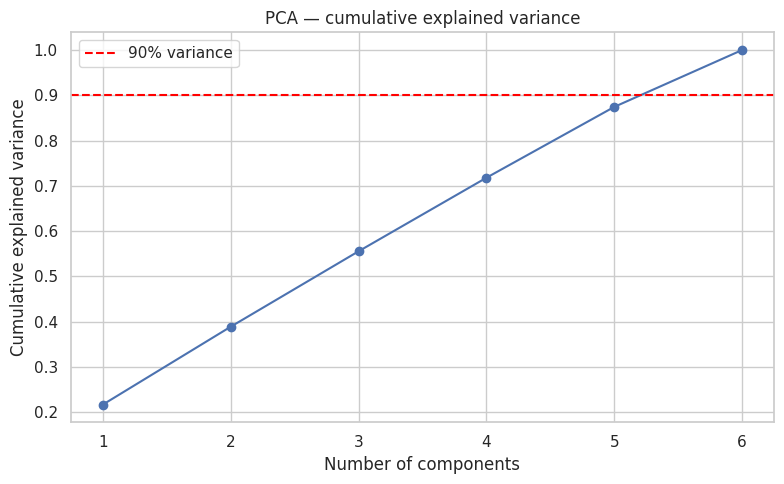

6 components explain >=90% of variance (out of 6 numeric features)


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca_numeric_cols = [c for c in selected_features if c in numeric_cols]
pca_input = X_train_final[pca_numeric_cols].fillna(X_train_final[pca_numeric_cols].median())

scaler_for_pca = StandardScaler()
pca_input_scaled = scaler_for_pca.fit_transform(pca_input)

pca_full = PCA(random_state=RANDOM_STATE).fit(pca_input_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
plt.axhline(0.90, color="red", linestyle="--", label="90% variance")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA — cumulative explained variance")
plt.legend()
plt.tight_layout()
plt.show()

n_components_90 = int(np.argmax(cum_var >= 0.90) + 1)
print(f"{n_components_90} components explain >=90% of variance "
      f"(out of {pca_input.shape[1]} numeric features)")


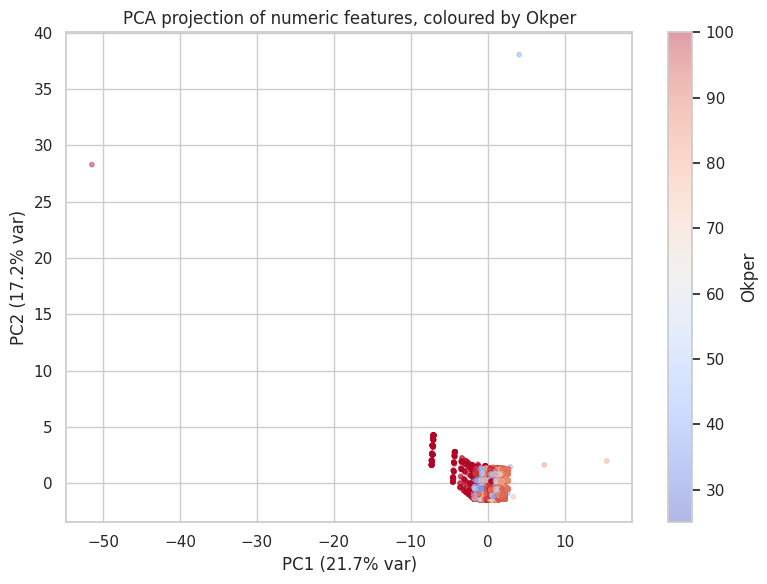

In [ ]:
# 2D projection coloured by Okper -- a quick look for unmodeled structure/clusters.
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca_2d.fit_transform(pca_input_scaled)

plt.figure(figsize=(8, 6))
sc = plt.scatter(coords[:, 0], coords[:, 1], c=y_train_full.values, cmap="coolwarm", alpha=0.4, s=10)
plt.colorbar(sc, label=TARGET)
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} var)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} var)")
plt.title("PCA projection of numeric features, coloured by Okper")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# PCA-as-features pipeline component, reused in Section 11 for the linear/SVR/KNN
# baselines. n_components_90 was computed above from the training fold only.
pca_transformer = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("pca", PCA(n_components=n_components_90, random_state=RANDOM_STATE)),
])
pca_transformer


Pipeline(steps=[('impute', SimpleImputer(strategy='median')),
                ('scale', StandardScaler()),
                ('pca', PCA(n_components=6, random_state=42))])

## 10. Preprocessing Pipeline & Cross-Validation Strategy

One `ColumnTransformer` handles numeric imputing/scaling and categorical imputing/encoding, wrapped together with the model in a single `Pipeline`. For cross-validation we use `TimeSeriesSplit` (each fold trains on the past, validates on the future) instead of vanilla `KFold`, matching the real-world usage pattern and avoiding the same leakage risk discussed in Section 7.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.metrics import make_scorer, r2_score, mean_absolute_error, mean_squared_error

final_numeric_cols = [c for c in selected_features if c in numeric_cols]
final_categorical_cols = [c for c in selected_features if c in categorical_cols]
print(f"{len(final_numeric_cols)} numeric + {len(final_categorical_cols)} categorical = "
      f"{len(selected_features)} total features")

preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), final_numeric_cols),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), final_categorical_cols),
])

cv = TimeSeriesSplit(n_splits=CONFIG["n_cv_splits"])

scoring = {
    "r2": make_scorer(r2_score),
    "neg_mae": make_scorer(mean_absolute_error, greater_is_better=False),
    "neg_rmse": make_scorer(lambda yt, yp: -np.sqrt(mean_squared_error(yt, yp))),
}


6 numeric + 5 categorical = 11 total features


## 11. Model Training — Baselines

Every model is wrapped in the same `preprocessor` and evaluated with identical, leakage-safe `TimeSeriesSplit` cross-validation, so the comparison table is apples-to-apples. We include linear, distance-based, tree and boosting families to get a real read on how much structure is (non-)linear.

In [ ]:
!pip install catboost

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

candidate_models = {
    # ---------------- Linear Models ----------------
    "LinearRegression": LinearRegression(),

    "Ridge": Ridge(
        alpha=1.0,
        random_state=RANDOM_STATE,
    ),

    "Lasso": Lasso(
        alpha=0.01,
        random_state=RANDOM_STATE,
        max_iter=5000,
    ),

    "ElasticNet": ElasticNet(
        alpha=0.01,
        l1_ratio=0.5,
        random_state=RANDOM_STATE,
        max_iter=5000,
    ),

    # ---------------- Tree Models ----------------
    "DecisionTree": DecisionTreeRegressor(
        max_depth=15,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
    ),

    "RandomForest": RandomForestRegressor(
        n_estimators=150,
        max_depth=20,
        min_samples_leaf=2,
        max_features="sqrt",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),

    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=150,
        max_depth=20,
        min_samples_leaf=2,
        max_features="sqrt",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),

    # ---------------- Other Models ----------------
    # "SVR": SVR(
    #     C=10,
    #     epsilon=0.1,
    #     kernel="rbf",
    # ),

    # "KNN": KNeighborsRegressor(
    #     n_neighbors=10,
    #     weights="distance",
    #     n_jobs=-1,
    # ),

    # ---------------- Boosting Models ----------------
    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        max_bin=128,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbosity=0,
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=200,
        learning_rate=0.1,
        num_leaves=31,
        max_depth=10,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbosity=-1,
    ),

    "CatBoost": CatBoostRegressor(
        iterations=200,
        learning_rate=0.1,
        depth=6,
        random_state=RANDOM_STATE,
        verbose=False,
    ),
}

In [ ]:
from tqdm.auto import tqdm
from sklearn.base import clone
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import time

In [ ]:
def evaluate_with_cv(model, X, y, preprocessor, cv):
    r2_scores = []
    mae_scores = []
    rmse_scores = []

    start = time.time()

    total_folds = cv.get_n_splits(X, y)

    with tqdm(total=total_folds,
              desc=type(model).__name__,
              leave=False,
              unit="fold") as pbar:

        for train_idx, val_idx in cv.split(X, y):

            X_train = X.iloc[train_idx]
            X_val   = X.iloc[val_idx]

            y_train = y.iloc[train_idx]
            y_val   = y.iloc[val_idx]

            pipe = Pipeline([
                ("preprocessor", clone(preprocessor)),
                ("model", clone(model))
            ])

            pipe.fit(X_train, y_train)

            preds = pipe.predict(X_val)

            r2_scores.append(r2_score(y_val, preds))
            mae_scores.append(mean_absolute_error(y_val, preds))
            rmse_scores.append(np.sqrt(mean_squared_error(y_val, preds)))

            pbar.update(1)

    elapsed = time.time() - start

    return {
        "R2_mean": np.mean(r2_scores),
        "R2_std": np.std(r2_scores),
        "MAE_mean": np.mean(mae_scores),
        "MAE_std": np.std(mae_scores),
        "RMSE_mean": np.mean(rmse_scores),
        "RMSE_std": np.std(rmse_scores),
        "fit_time_s": round(elapsed, 1),
    }

In [ ]:
baseline_results = {}

with tqdm(candidate_models.items(),
          total=len(candidate_models),
          desc="Training Models",
          unit="model") as model_bar:

    for name, model in model_bar:

        model_bar.set_postfix(model=name)

        baseline_results[name] = evaluate_with_cv(
            model,
            X_train_final,
            y_train_full,
            preprocessor,
            cv,
        )

baseline_results_df = (
    pd.DataFrame(baseline_results)
      .T
      .sort_values("R2_mean", ascending=False)
)

baseline_results_df

Training Models:   0%|          | 0/10 [00:00<?, ?model/s]

LinearRegression:   0%|          | 0/3 [00:00<?, ?fold/s]

Ridge:   0%|          | 0/3 [00:00<?, ?fold/s]

Lasso:   0%|          | 0/3 [00:00<?, ?fold/s]

ElasticNet:   0%|          | 0/3 [00:00<?, ?fold/s]

...

ExtraTreesRegressor:   0%|          | 0/3 [00:00<?, ?fold/s]

XGBRegressor:   0%|          | 0/3 [00:00<?, ?fold/s]

LGBMRegressor:   0%|          | 0/3 [00:00<?, ?fold/s]

CatBoostRegressor:   0%|          | 0/3 [00:00<?, ?fold/s]

,R2_mean,R2_std,MAE_mean,MAE_std,RMSE_mean,RMSE_std,fit_time_s
LightGBM,6.182418e-01,5.230672e-02,6.713492,0.998654,9.549065e+00,1.068515e+00,1.8
XGBoost,6.042831e-01,4.918485e-02,6.904166,0.950252,9.721284e+00,1.001693e+00,3.6
CatBoost,6.006486e-01,5.988347e-02,6.879626,0.966078,9.759715e+00,1.100127e+00,3.7
RandomForest,5.428090e-01,6.762865e-02,7.438987,1.036758,1.044399e+01,1.177766e+00,33.8
ExtraTrees,4.896810e-01,7.298735e-02,7.795122,1.132388,1.103923e+01,1.264788e+00,23.1
DecisionTree,4.078153e-01,2.991220e-02,8.044069,1.092250,1.189729e+01,8.641709e-01,3.3
Lasso,-2.657267e+11,3.757944e+11,42467.034052,60045.465918,4.792739e+06,6.777940e+06,26.1
Ridge,-2.688503e+11,3.802118e+11,42715.834959,60397.317460,4.820826e+06,6.817661e+06,1.0
LinearRegression,-2.701036e+11,3.819841e+11,42815.282436,60537.912290,4.832049e+06,6.833532e+06,1.7
ElasticNet,-2.874289e+11,4.064859e+11,44166.852439,62449.340777,4.984612e+06,7.049289e+06,9.3


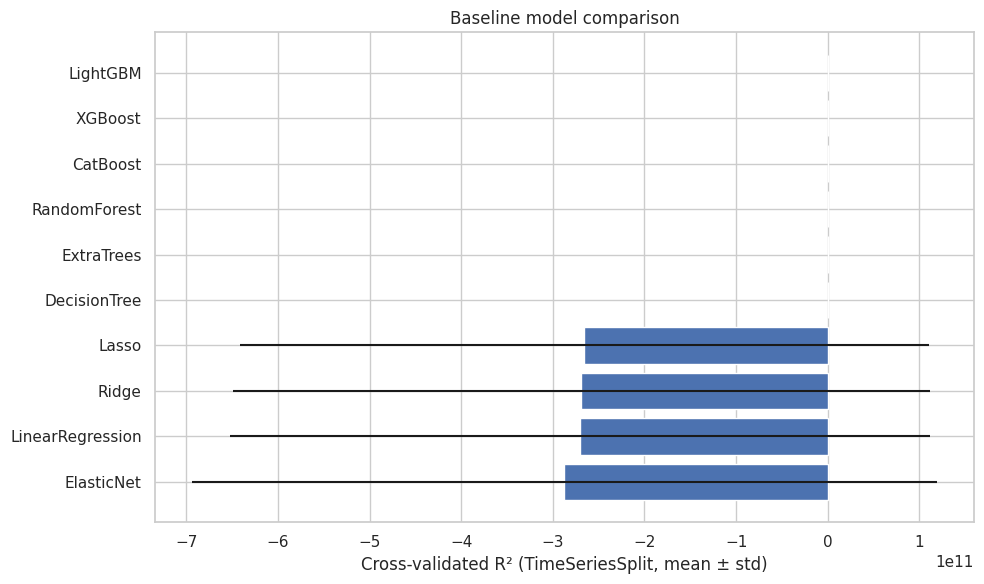

In [ ]:
plt.figure(figsize=(10, 6))
order = baseline_results_df.index
plt.barh(order, baseline_results_df["R2_mean"], xerr=baseline_results_df["R2_std"])
plt.gca().invert_yaxis()
plt.xlabel("Cross-validated R² (TimeSeriesSplit, mean ± std)")
plt.title("Baseline model comparison")
plt.tight_layout()
plt.show()


**Reading the table:** tree/boosting ensembles are expected to dominate given the strong categorical + non-linear interaction structure seen in EDA (Product×Colour heatmaps, defect-stage thresholds). The top 2–3 models here are carried forward into hyperparameter tuning (Section 12) and ensembling (Section 13) — no point tuning a model family that's clearly outclassed on the baseline pass.

## 12. Hyperparameter Tuning — Optuna

We tune the top boosting models with `Optuna`'s TPE sampler. The objective function cross-validates on the **same `TimeSeriesSplit`** used for the baselines — a search that only looked at a single train/valid split would happily overfit to that one split's quirks. Pruning is enabled so clearly-bad trials stop early instead of burning the full budget.

In [ ]:
!pip install optuna

In [ ]:
import optuna
from optuna.pruners import MedianPruner
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)


def make_xgb_objective(X, y, preprocessor, cv):
    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 200, 1200),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        }
        model = XGBRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist")
        pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
        scores = cross_val_score(pipe, X, y, cv=cv, scoring="r2", n_jobs=1)
        return scores.mean()
    return objective


def make_lgbm_objective(X, y, preprocessor, cv):
    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 200, 1200),
            "num_leaves": trial.suggest_int("num_leaves", 15, 127),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 60),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        }
        model = LGBMRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)
        pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
        scores = cross_val_score(pipe, X, y, cv=cv, scoring="r2", n_jobs=1)
        return scores.mean()
    return objective


In [ ]:
N_TRIALS = CONFIG["n_optuna_trials"]
tuned_models = {}
tuning_summary = {}

objectives = {
    "XGBoost": make_xgb_objective(X_train_final, y_train_full, preprocessor, cv),
    "LightGBM": make_lgbm_objective(X_train_final, y_train_full, preprocessor, cv),
    # "RandomForest": make_rf_objective(X_train_final, y_train_full, preprocessor, cv),
}

for name, objective in objectives.items():
    logger.info("Tuning %s with Optuna (%d trials) ...", name, N_TRIALS)
    study = optuna.create_study(direction="maximize", pruner=MedianPruner(),
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    tuning_summary[name] = {"best_r2_cv": study.best_value, "best_params": study.best_params}
    logger.info("%s best CV R2 = %.4f", name, study.best_value)

    if name == "XGBoost":
        tuned_models[name] = XGBRegressor(**study.best_params, random_state=RANDOM_STATE,
                                           n_jobs=-1, tree_method="hist")
    elif name == "LightGBM":
        tuned_models[name] = LGBMRegressor(**study.best_params, random_state=RANDOM_STATE,
                                            n_jobs=-1, verbosity=-1)
    # elif name == "RandomForest":
    #     tuned_models[name] = RandomForestRegressor(**study.best_params, random_state=RANDOM_STATE, n_jobs=-1)

pd.DataFrame({k: v["best_params"] | {"best_r2_cv": v["best_r2_cv"]} for k, v in tuning_summary.items()}).T


  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,reg_alpha,reg_lambda,best_r2_cv,num_leaves,min_child_samples
XGBoost,678.0,8.0,0.040319,0.599354,0.780058,8.0,0.000554,6.495886e+00,0.621807,NaN,NaN
LightGBM,699.0,NaN,0.014512,0.550651,0.672115,NaN,0.000554,5.837557e-08,0.624682,127.0,25.0


In [ ]:
with open(CONFIG["report_dir"] / "optuna_best_params.json", "w") as f:
    json.dump({k: v["best_params"] for k, v in tuning_summary.items()}, f, indent=2)
logger.info("Saved best hyperparameters -> %s", CONFIG["report_dir"] / "optuna_best_params.json")


**Model selection rule:** promote the ensemble to production only if it beats the single best tuned model by more than one standard deviation of CV R² — otherwise prefer the simpler single model (fewer moving parts to monitor and retrain in production, per the maintainability discussion in Section 16).

In [ ]:
# Select the best tuned model
best_single_name = max(
    tuned_models,
    key=lambda n: tuning_summary[n]["best_r2_cv"]
)

best_single_r2 = tuning_summary[best_single_name]["best_r2_cv"]

print(f"Best tuned model : {best_single_name}")
print(f"Best CV R²       : {best_single_r2:.4f}")

FINAL_MODEL_NAME = best_single_name
FINAL_MODEL = tuned_models[best_single_name]

print("Selected for production:", FINAL_MODEL_NAME)

Best tuned model : LightGBM
Best CV R²       : 0.6247
Selected for production: LightGBM


## 14. Final Evaluation on the Held-Out (Future) Test Set

Everything above only ever touched `X_train_final` / `y_train_full`. This is the **first and only** time the test set is used — refit the selected model on the full training window and score it once on the untouched, chronologically-later test slice.

In [ ]:
from sklearn.pipeline import Pipeline

final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", FINAL_MODEL)
])

final_pipeline.fit(X_train_final, y_train_full)

test_preds = final_pipeline.predict(X_test_final)

In [ ]:
final_metrics = {
    "R2": r2_score(y_test, test_preds),
    "MAE": mean_absolute_error(y_test, test_preds),
    "RMSE": np.sqrt(mean_squared_error(y_test, test_preds)),
    "MAPE_%": float(np.mean(np.abs((y_test - test_preds) / y_test.replace(0, np.nan))) * 100),
}
print(f"Held-out test performance ({FINAL_MODEL_NAME}):")
for k, v in final_metrics.items():
    print(f"  {k}: {v:.4f}")


Held-out test performance (LightGBM):
  R2: 0.6601
  MAE: 7.9452
  RMSE: 10.5418
  MAPE_%: 12.7193


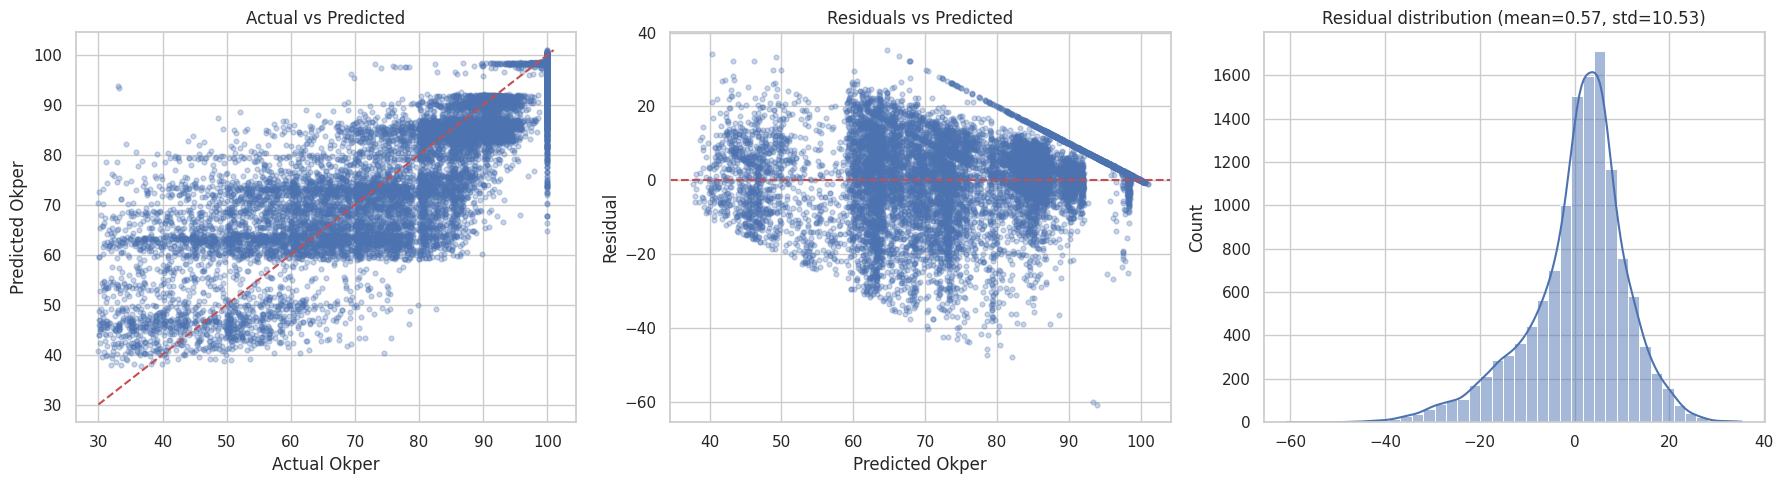

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, test_preds, alpha=0.3, s=12)
lims = [min(y_test.min(), test_preds.min()), max(y_test.max(), test_preds.max())]
axes[0].plot(lims, lims, "r--")
axes[0].set_xlabel("Actual Okper"); axes[0].set_ylabel("Predicted Okper")
axes[0].set_title("Actual vs Predicted")

residuals = y_test.values - test_preds
axes[1].scatter(test_preds, residuals, alpha=0.3, s=12)
axes[1].axhline(0, color="r", linestyle="--")
axes[1].set_xlabel("Predicted Okper"); axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs Predicted")

sns.histplot(residuals, bins=40, kde=True, ax=axes[2])
axes[2].set_title(f"Residual distribution (mean={residuals.mean():.2f}, std={residuals.std():.2f})")

plt.tight_layout()
plt.show()


### 14.1 Error by segment

Aggregate metrics can hide a model that's great on 90% of products and useless on the other 10%. Breaking MAE down by Product / Colour tells Quality *where* to trust the model and where to keep manual review.

In [ ]:
error_by_product = (
    pd.DataFrame({"ProductNumber": test_df["ProductNumber"].values, "abs_error": np.abs(residuals)})
    .groupby("ProductNumber")["abs_error"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)
print("Hardest-to-predict products (highest mean absolute error):")
error_by_product.head(15)


Hardest-to-predict products (highest mean absolute error):


,mean,count
ProductNumber,,
5842.0,22.747966,9
5840.0,20.783276,12
5811.0,20.326329,28
5843.0,14.980768,14
5821.0,13.363521,16
5860.0,12.216302,6
5817.0,12.022705,166
5816.0,11.604799,17
5818.0,11.522536,1041


In [ ]:
error_by_colour = (
    pd.DataFrame({"ColourCode": test_df["ColourCode"].values, "abs_error": np.abs(residuals)})
    .groupby("ColourCode")["abs_error"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)
print("Hardest-to-predict colours (highest mean absolute error):")
error_by_colour.head(15)


Hardest-to-predict colours (highest mean absolute error):


,mean,count
ColourCode,,
770.0,18.676171,1
708.0,17.899707,4
2028.0,14.373763,14
2029.0,12.323196,10
674.0,11.743312,33
2014.0,11.629471,10
769.0,11.185334,41
731.0,10.374943,94
616.0,10.043145,462


### 14.2 Learning curve

Sanity-checks whether we're data-starved (curve still rising -> more data would help) or have plateaued (curve flat -> more feature/model work matters more than more rows).

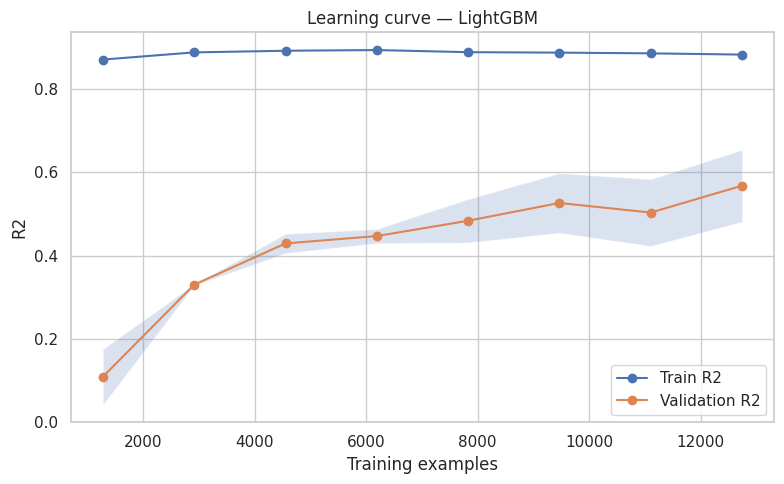

In [ ]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    Pipeline([("preprocessor", preprocessor), ("model", tuned_models[best_single_name])]),
    X_train_final, y_train_full, cv=cv, scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=1,
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Train R2")
plt.plot(train_sizes, val_scores.mean(axis=1), "o-", label="Validation R2")
plt.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                  val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.2)
plt.xlabel("Training examples"); plt.ylabel("R2")
plt.title(f"Learning curve — {best_single_name}")
plt.legend(); plt.tight_layout(); plt.show()


## 15. Feature Importance & Explainability

Three complementary views, from cheapest/least trustworthy to most rigorous:

1. **Built-in importances** (impurity-based) — fast, but biased toward high-cardinality features.
2. **Permutation importance** on the held-out test set — model-agnostic, answers "how much does shuffling this column actually hurt held-out performance", which is what stakeholders actually care about.
3. **SHAP** — per-prediction attribution, lets you explain *why* one specific batch is predicted to run at 62% instead of the average 85%.

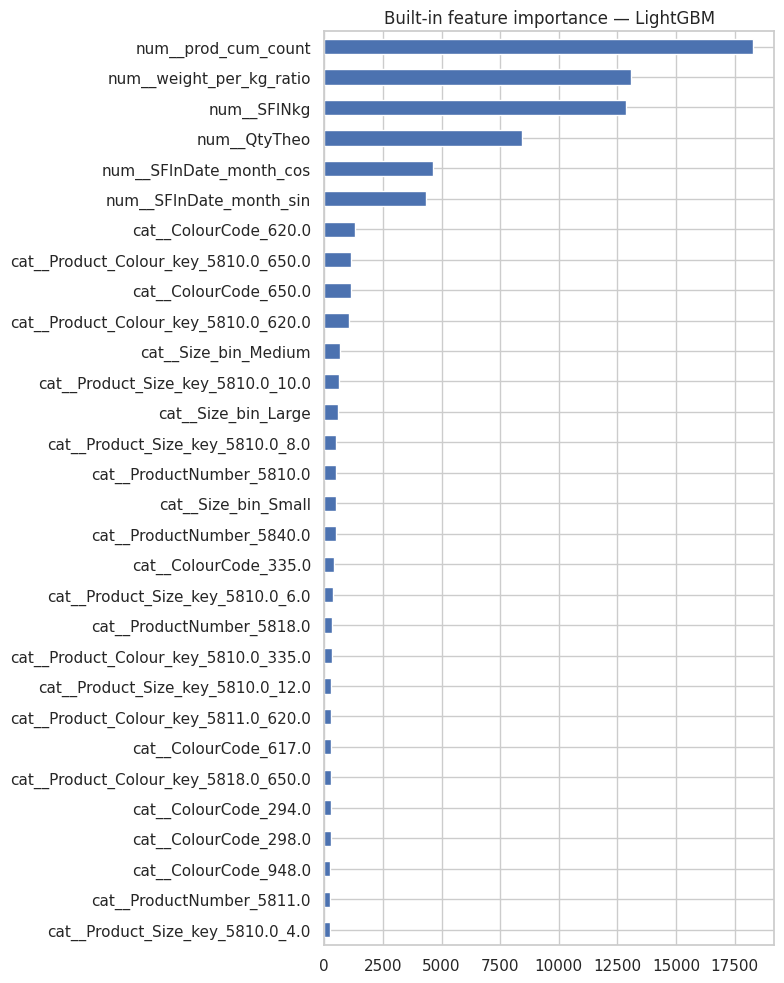

In [ ]:
best_tree_pipe = Pipeline([("preprocessor", preprocessor), ("model", tuned_models[best_single_name])])
best_tree_pipe.fit(X_train_final, y_train_full)

feature_names = best_tree_pipe.named_steps["preprocessor"].get_feature_names_out()
importances = best_tree_pipe.named_steps["model"].feature_importances_

imp_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)
plt.figure(figsize=(8, 10))
imp_series.head(30).sort_values().plot(kind="barh")
plt.title(f"Built-in feature importance — {best_single_name}")
plt.tight_layout()
plt.show()


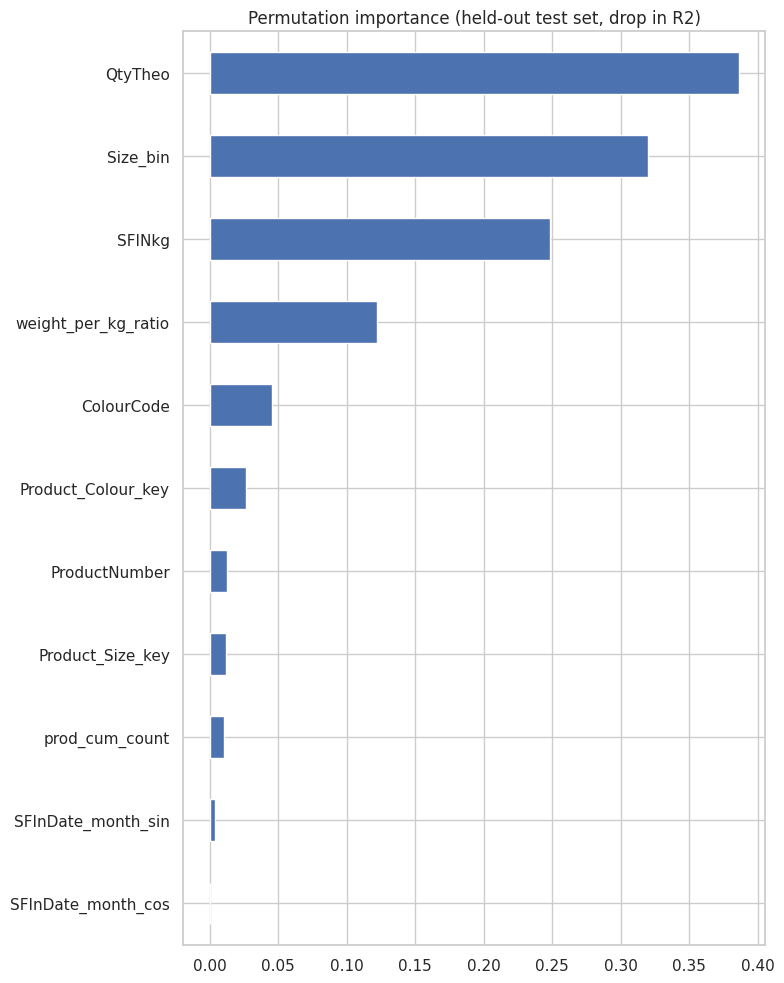

In [ ]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    best_tree_pipe, X_test_final, y_test, n_repeats=10,
    random_state=RANDOM_STATE, n_jobs=-1, scoring="r2",
)
perm_series = pd.Series(perm_result.importances_mean, index=X_test_final.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 10))
perm_series.head(30).sort_values().plot(kind="barh")
plt.title("Permutation importance (held-out test set, drop in R2)")
plt.tight_layout()
plt.show()


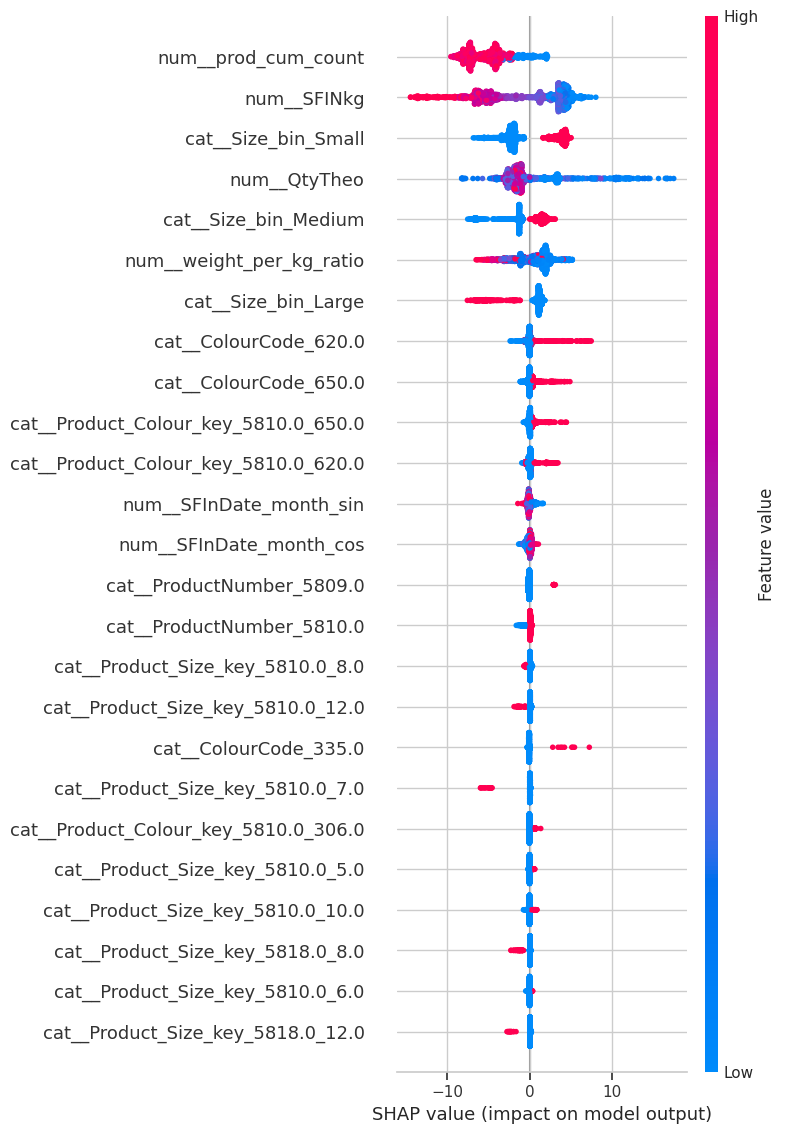

In [ ]:
import shap
import numpy as np

# 1. Transform the data
X_test_transformed = best_tree_pipe.named_steps["preprocessor"].transform(X_test_final)

# 2. RANDOMLY SAMPLE ~2,000 ROWS to speed up computation
# If your dataset is huge, 2000 is plenty for a representative summary plot
sample_size = min(2000, X_test_transformed.shape[0])
sample_indices = np.random.choice(X_test_transformed.shape[0], sample_size, replace=False)

X_test_sample = X_test_transformed[sample_indices]

# 3. Only convert the small sample to a dense array (saves massive memory)
if hasattr(X_test_sample, "toarray"):
    X_test_sample = X_test_sample.toarray()

# 4. Initialize Explainer
explainer = shap.TreeExplainer(best_tree_pipe.named_steps["model"])

# 5. Calculate SHAP values for the sample
# check_additivity=False skips an internal sanity check that can sometimes hang on LightGBM
shap_values = explainer.shap_values(X_test_sample, check_additivity=False)

# 6. Plot
shap.summary_plot(
    shap_values,
    X_test_sample,
    feature_names=feature_names,
    max_display=25,
    show=False
)
plt.tight_layout()
plt.show()

Actual: 33.11  Predicted: 93.84695872733049


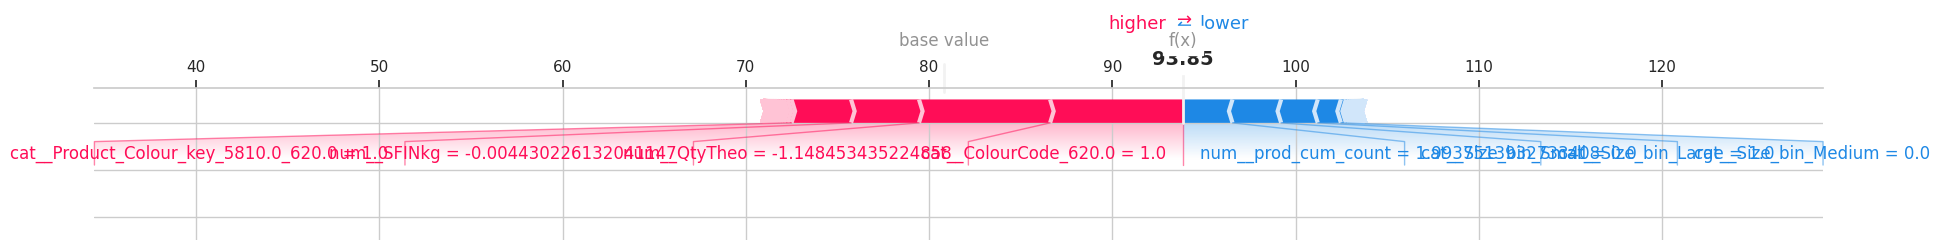

In [ ]:
import numpy as np
import shap
import matplotlib.pyplot as plt

# 1. Find the worst prediction across the ENTIRE test set
worst_idx = int(np.argmax(np.abs(residuals)))
print("Actual:", y_test.iloc[worst_idx], " Predicted:", test_preds[worst_idx])

# 2. Extract ONLY that specific row
worst_row = X_test_transformed[worst_idx]

# 3. Convert sparse matrix to dense array for this single row
if hasattr(worst_row, "toarray"):
    worst_row = worst_row.toarray()
elif hasattr(worst_row, "todense"):
    worst_row = worst_row.todense()

# Ensure it's a 2D array for the explainer (1 row, N columns)
worst_row = np.array(worst_row).reshape(1, -1)

# 4. Calculate SHAP values for JUST this one row
# (This takes milliseconds)
single_shap_value = explainer.shap_values(worst_row, check_additivity=False)

# 5. Plot the force plot
shap.force_plot(
    explainer.expected_value,
    single_shap_value[0], # Get the values for the 1st (and only) row
    worst_row[0],         # Get the features for the 1st (and only) row
    feature_names=feature_names,
    matplotlib=True,
    show=False
)
plt.tight_layout()
plt.show()

## 16. Production Artifacts

Save everything a batch-scoring job or a small API needs: the fitted pipeline, the exact feature list/order, the config, and metadata (training window, metrics, git-style version tag). A thin `predict_okper()` wrapper does input validation so a malformed upstream record fails loudly instead of silently producing a bogus yield forecast.

In [ ]:
import joblib
from datetime import datetime

MODEL_VERSION = datetime.now().strftime("okper_model_%Y%m%d_%H%M%S")
model_path = CONFIG["model_dir"] / f"{MODEL_VERSION}.joblib"

artifact = {
    "pipeline": FINAL_MODEL,
    "feature_columns": list(X_train_final.columns),
    "target": TARGET,
    "config": CONFIG,
    "metrics": final_metrics,
    "trained_at": datetime.now().isoformat(),
    "train_window": [str(train_df[CONFIG["date_col"]].min()), str(train_df[CONFIG["date_col"]].max())],
    "model_name": FINAL_MODEL_NAME,
}
joblib.dump(artifact, model_path)
logger.info("Saved production artifact -> %s", model_path)


In [ ]:
import pandas as pd
import numpy as np
import joblib
import logging

logger = logging.getLogger(__name__)

def predict_okper(raw_batch_df: pd.DataFrame, artifact_path=model_path) -> pd.DataFrame:
    """Score new, unseen batches end-to-end: clean -> feature-engineer -> predict.

    `raw_batch_df` should have the same raw schema as the source Excel export
    (i.e. pre-cleaning). Returns the input augmented with a `predicted_okper` column.
    """
    artifact = joblib.load(artifact_path)
    cfg = artifact["config"]

    # 1. Clean the data (Note: your clean_dataset must not drop rows during inference!)
    cleaned = clean_dataset(raw_batch_df, product_code, colour_code, target=cfg["target"]) \
        if cfg["target"] in raw_batch_df.columns else raw_batch_df

    # 2. Add engineered features
    featured = add_static_features(cleaned, cfg)

    # 3. Handle missing columns required by the model
    missing_cols = set(artifact["feature_columns"]) - set(featured.columns)
    for col in missing_cols:
        featured[col] = np.nan
        logger.warning("Column '%s' missing at inference time -- imputing", col)

    # 4. Subset to exactly what the model expects
    X_new = featured[artifact["feature_columns"]].copy()

    # ---------------------------------------------------------
    # THE FIX: Cast all string/object columns to 'category'
    # ---------------------------------------------------------
    for col in X_new.select_dtypes(include=['object', 'string']).columns:
        X_new[col] = X_new[col].astype('category')
    # ---------------------------------------------------------

    # 5. Predict
    preds = artifact["pipeline"].predict(X_new)

    # 6. Attach predictions back to the original dataframe
    result = raw_batch_df.copy()

    # Ensure length matches (in case clean_dataset dropped any corrupted inference rows)
    if len(result) == len(preds):
        result["predicted_okper"] = preds
    else:
        logger.warning("Row count mismatch! Attach predictions carefully.")
        # If your clean dataset dropped rows, you might need to merge on an index instead.

    return result

## 17. Summary & Next Steps

**What this notebook produces:**
- A cleaned, validated dataset with a logged, auditable cleaning pipeline.
- Leakage-safe engineered features (causal historical aggregates, defect-stage sums, calendar features).
- A reproducible feature-selection funnel (variance → correlation/VIF → mutual information) that's re-runnable on new data drops.
- A benchmarked set of baseline, tuned, and ensembled models, all validated with time-respecting cross-validation.
- Full explainability (built-in + permutation importance + SHAP) and segment-level error analysis so Quality/Planning know when to trust the number.
- A versioned, joblib-persisted production artifact with a single `predict_okper()` entry point.

**Recommended next steps before shipping to production:**
1. **Backtesting** — replay the pipeline over multiple historical time windows (not just one train/test split) to confirm performance is stable across seasons and across the 2018→2024 span, not just the most recent slice.
2. **Monitoring** — track prediction drift and feature drift (e.g. a new ColourCode never seen in training) once deployed; the `n_hist` / cold-start columns from Section 6 are a natural drift signal to watch.
3. **Retraining cadence** — decide how often (e.g. monthly) the pipeline re-fits on the latest data; the causal, expanding-window features make this a clean, well-defined operation.
4. **A/B or shadow deployment** — run the model's predictions alongside the current manual estimation process for a period before it drives decisions.
5. **Business threshold calibration** — decide what MAE / error tolerance is actually acceptable for a planning decision, and whether a prediction interval (e.g. via quantile regression or conformal prediction) is more useful to the business than a single point estimate.